In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, f1_score, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.utils import resample
from sklearn.metrics.pairwise import pairwise_distances
import optuna
import seaborn as sns
from knn_handmade import KNNHandMade
%matplotlib inline

### Загрузка данных

In [11]:
models = []

In [12]:
data = pd.read_csv('data/k4_eda.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47358 entries, 0 to 47357
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   UTC             47358 non-null  int64  
 1   Temperature[C]  47358 non-null  float64
 2   Humidity[%]     47358 non-null  float64
 3   TVOC[ppb]       47358 non-null  float64
 4   eCO2[ppm]       47358 non-null  float64
 5   Raw H2          47358 non-null  int64  
 6   Raw Ethanol     47358 non-null  int64  
 7   Pressure[hPa]   47358 non-null  float64
 8   PM1.0           47358 non-null  float64
 9   PM2.5           47358 non-null  float64
 10  NC0.5           47358 non-null  float64
 11  NC1.0           47358 non-null  float64
 12  NC2.5           47358 non-null  float64
 13  Fire Alarm      47358 non-null  bool   
dtypes: bool(1), float64(10), int64(3)
memory usage: 4.7 MB


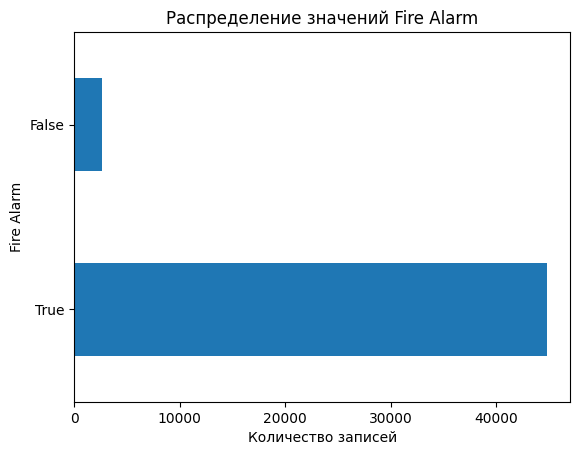

In [13]:
data['Fire Alarm'].value_counts().plot(kind='barh')
plt.title('Распределение значений Fire Alarm')
plt.xlabel('Количество записей')
plt.ylabel('Fire Alarm')
plt.show()

### Балансировка классов

In [14]:
feature_data = data.drop(['Fire Alarm'], axis=1)
labels_data = data['Fire Alarm']
oversample = SMOTE()
transformed_feature_data, transformed_labels_data = oversample.fit_resample(feature_data, labels_data)

In [15]:
print("Распределение классов после SMOTE:")
print(transformed_labels_data.value_counts())

Распределение классов после SMOTE:
Fire Alarm
True     44757
False    44757
Name: count, dtype: int64


### Объединение и перемешивание данных

In [16]:
data_balanced = pd.concat([transformed_feature_data, transformed_labels_data], axis=1)
data_balanced = data_balanced.sample(frac=1, random_state=42).reset_index(drop=True)
data_balanced.to_csv('data/k4_balanced.csv', index=False)

### Подготовка данных

In [17]:
X = data_balanced.drop(columns=['Fire Alarm', 'UTC'])
y = data_balanced['Fire Alarm']
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### Функция для оценки модели

In [18]:
def evaluate_model(model, X_test, y_test, model_name="Model", verbose=True):
    y_pred = model.predict(X_test)
    y_scores = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    if verbose:
        print(f"\n--- {model_name} ---")
        print("Classification Report:")
        print(classification_report(y_test, y_pred))
        print("Confusion Matrix:")
        print(confusion_matrix(y_test, y_pred))
        print(f"F1-score: {f1_score(y_test, y_pred):.4f}")

        plt.figure(figsize=(8, 3))
        jitter = 0.05
        x = np.arange(len(y_test))
        y_true_jittered = y_test + np.random.uniform(-jitter, jitter, size=len(y_test))
        y_pred_jittered = y_pred + np.random.uniform(-jitter, jitter, size=len(y_pred))
        plt.scatter(x, y_true_jittered, alpha=0.6, label='y_test (true)', color='blue', s=10)
        plt.scatter(x, y_pred_jittered, alpha=0.6, label='y_pred (predicted)', color='red', s=10)
        plt.yticks([0, 1])
        plt.ylim(-0.2, 1.2)
        plt.xlabel("Индекс образца")
        plt.ylabel("Класс")
        plt.title(f'Распределение y_test и y_pred для {model_name}')
        plt.legend()
        plt.tight_layout()
        plt.show()

        if y_scores is not None:
            fpr, tpr, _ = roc_curve(y_test, y_scores)
            auc = roc_auc_score(y_test, y_scores)
            plt.figure(figsize=(6, 6))
            plt.plot([0, 1], [0, 1], 'k--')
            plt.plot(fpr, tpr)
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.title(f'ROC Curve for {model_name} (AUC = {auc:.2f})')
            plt.show()
            print(f"AUC: {auc:.2f}")
    else:
        auc = roc_auc_score(y_test, y_scores) if y_scores is not None else np.nan

    return {
        "model": model_name,
        "f1": f1_score(y_test, y_pred),
        "accuracy": accuracy_score(y_test, y_pred),
        "auc": auc
    }

### Logistic Regression


--- Logistic Regression ---
Classification Report:
              precision    recall  f1-score   support

       False       1.00      1.00      1.00     13428
        True       1.00      1.00      1.00     13427

    accuracy                           1.00     26855
   macro avg       1.00      1.00      1.00     26855
weighted avg       1.00      1.00      1.00     26855

Confusion Matrix:
[[13417    11]
 [   26 13401]]
F1-score: 0.9986


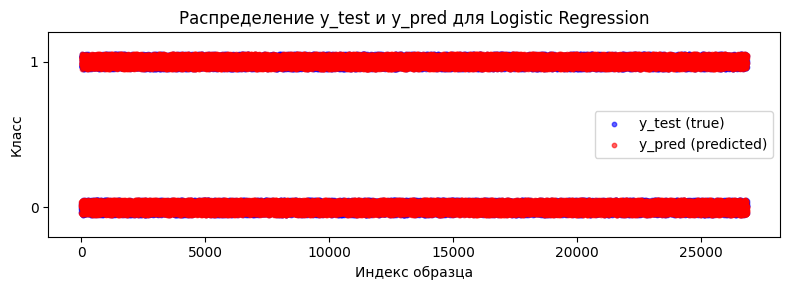

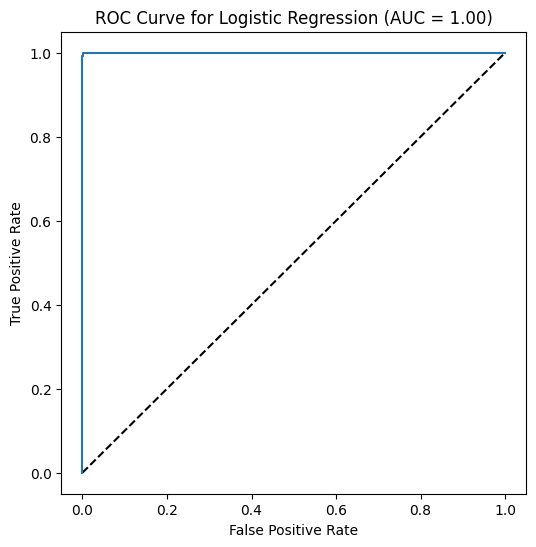

AUC: 1.00


{'model': 'Logistic Regression',
 'f1': 0.9986214091434107,
 'accuracy': 0.9986222304971142,
 'auc': 0.9999586350924967}

In [19]:
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
evaluate_model(logreg, X_test, y_test, "Logistic Regression")

In [20]:
def objective_logreg(trial):
    C = trial.suggest_loguniform('C', 1e-3, 1e3)
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])
    model = LogisticRegression(C=C, penalty=penalty, solver='liblinear', random_state=42)
    return cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy').mean()


--- Logistic Regression (Optimized) ---
Classification Report:
              precision    recall  f1-score   support

       False       0.96      1.00      0.98     13428
        True       1.00      0.95      0.98     13427

    accuracy                           0.98     26855
   macro avg       0.98      0.98      0.98     26855
weighted avg       0.98      0.98      0.98     26855

Confusion Matrix:
[[13381    47]
 [  610 12817]]
F1-score: 0.9750


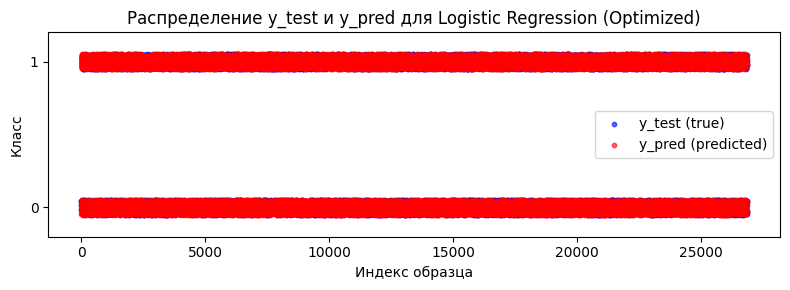

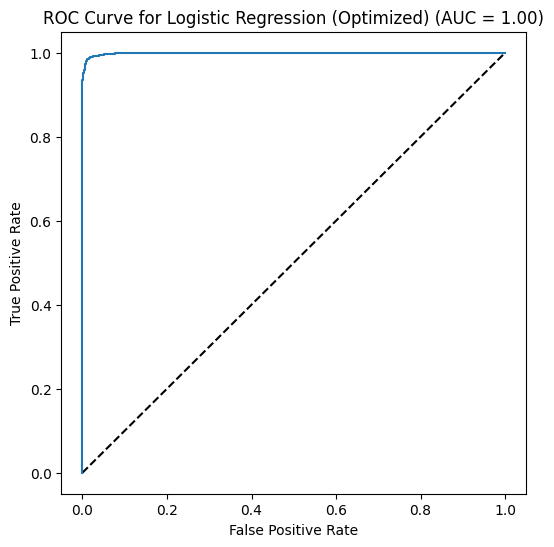

AUC: 1.00


In [21]:
# study_logreg = optuna.create_study(direction='maximize')
# study_logreg.optimize(objective_logreg, n_trials=50)
# print("Лучшие параметры для Logistic Regression:", study_logreg.best_params)
# logreg_best = LogisticRegression(**study_logreg.best_params, solver='liblinear', random_state=42)
logreg_best = LogisticRegression(C=0.0011407799502494878, penalty='l2', solver='liblinear', random_state=42)
logreg_best.fit(X_train, y_train)
evaluate_model(logreg_best, X_test, y_test, "Logistic Regression (Optimized)")

models.append(logreg_best)

### Naive Bayes


--- Naive Bayes ---
Classification Report:
              precision    recall  f1-score   support

       False       0.92      0.97      0.94     13428
        True       0.97      0.91      0.94     13427

    accuracy                           0.94     26855
   macro avg       0.94      0.94      0.94     26855
weighted avg       0.94      0.94      0.94     26855

Confusion Matrix:
[[13066   362]
 [ 1173 12254]]
F1-score: 0.9411


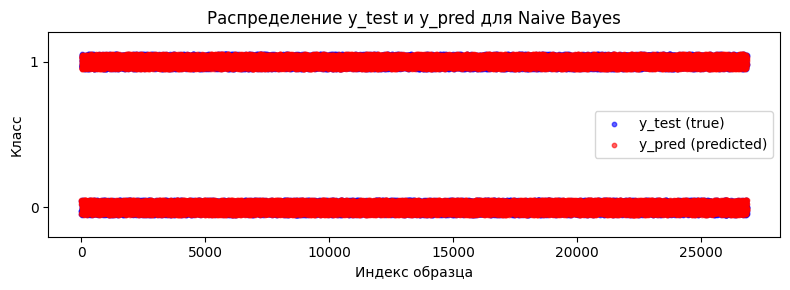

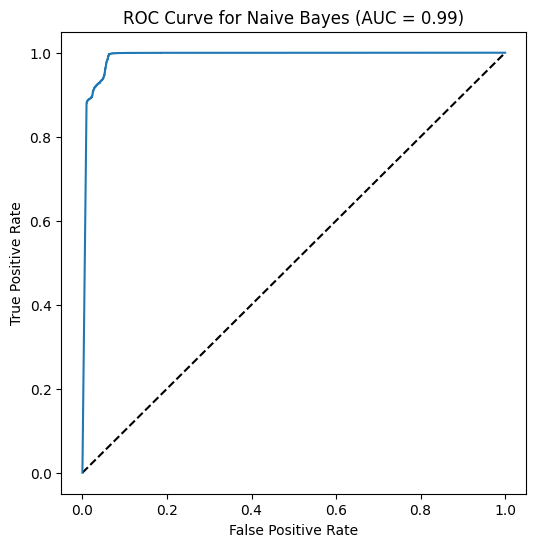

AUC: 0.99


{'model': 'Naive Bayes',
 'f1': 0.9410590177782897,
 'accuracy': 0.9428411841370322,
 'auc': 0.9906032496599679}

In [22]:
nb = GaussianNB()
nb.fit(X_train, y_train)
evaluate_model(nb, X_test, y_test, "Naive Bayes")

In [23]:
def objective_nb(trial):
    var_smoothing = trial.suggest_loguniform('var_smoothing', 1e-10, 1e-5)
    model = GaussianNB(var_smoothing=var_smoothing)
    return cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy').mean()


--- Naive Bayes (Optimized) ---
Classification Report:
              precision    recall  f1-score   support

       False       0.92      0.97      0.94     13428
        True       0.97      0.91      0.94     13427

    accuracy                           0.94     26855
   macro avg       0.94      0.94      0.94     26855
weighted avg       0.94      0.94      0.94     26855

Confusion Matrix:
[[13067   361]
 [ 1179 12248]]
F1-score: 0.9409


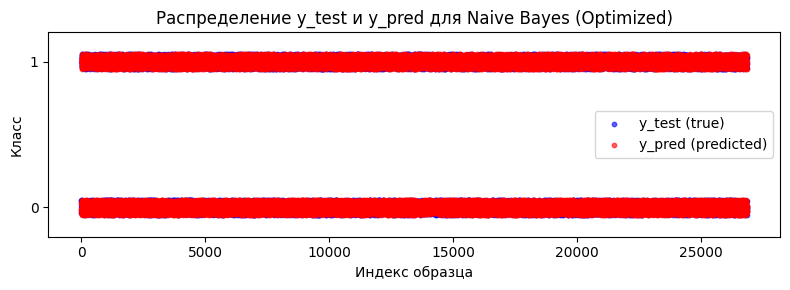

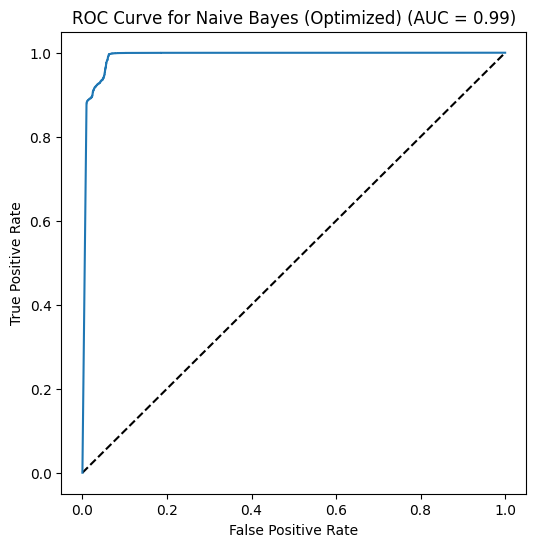

AUC: 0.99


In [24]:
# study_nb = optuna.create_study(direction='maximize')
# study_nb.optimize(objective_nb, n_trials=50)
# print("Лучшие параметры для Naive Bayes:", study_nb.best_params)
# nb_best = GaussianNB(**study_nb.best_params)
nb_best = GaussianNB(var_smoothing=8.260348576501791e-08)
nb_best.fit(X_train, y_train)
evaluate_model(nb_best, X_test, y_test, "Naive Bayes (Optimized)")

models.append(nb_best)

### KNN


--- KNN ---
Classification Report:
              precision    recall  f1-score   support

       False       1.00      1.00      1.00     13428
        True       1.00      1.00      1.00     13427

    accuracy                           1.00     26855
   macro avg       1.00      1.00      1.00     26855
weighted avg       1.00      1.00      1.00     26855

Confusion Matrix:
[[13428     0]
 [    0 13427]]
F1-score: 1.0000


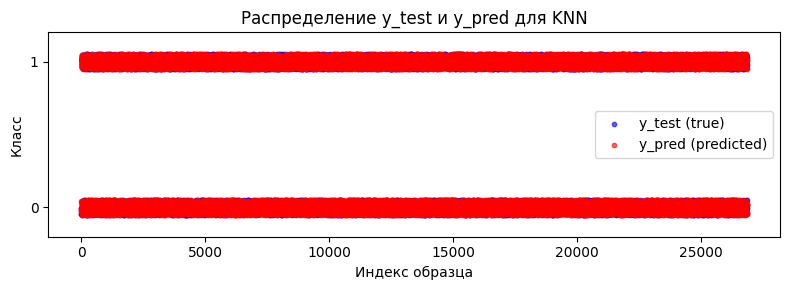

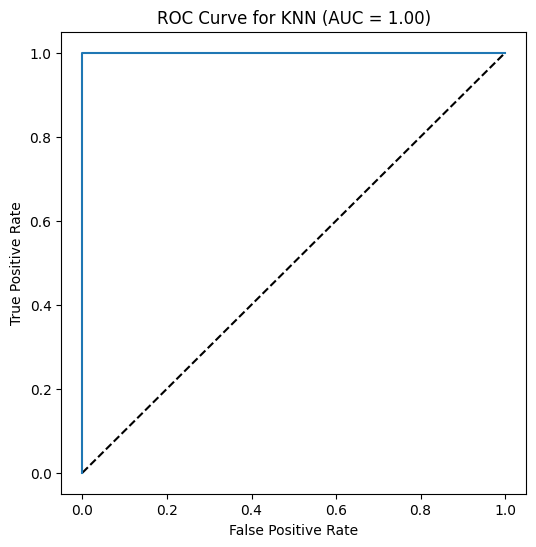

AUC: 1.00


{'model': 'KNN', 'f1': 1.0, 'accuracy': 1.0, 'auc': 1.0}

In [25]:
knn = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
knn.fit(X_train, y_train)
evaluate_model(knn, X_test, y_test, "KNN")

In [26]:
def objective_knn(trial):
    n_neighbors = trial.suggest_int('n_neighbors', 3, 15)
    weights = trial.suggest_categorical('weights', ['uniform', 'distance'])
    metric = trial.suggest_categorical('metric', ['euclidean', 'manhattan', 'minkowski', 'chebyshev'])
    p = trial.suggest_int('p', 1, 5) if metric == 'minkowski' else 2
    model = KNeighborsClassifier(n_neighbors=n_neighbors, weights=weights, metric=metric, p=p)
    return cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy').mean()


--- KNN (Optimized) ---
Classification Report:
              precision    recall  f1-score   support

       False       1.00      1.00      1.00     13428
        True       1.00      1.00      1.00     13427

    accuracy                           1.00     26855
   macro avg       1.00      1.00      1.00     26855
weighted avg       1.00      1.00      1.00     26855

Confusion Matrix:
[[13428     0]
 [    0 13427]]
F1-score: 1.0000


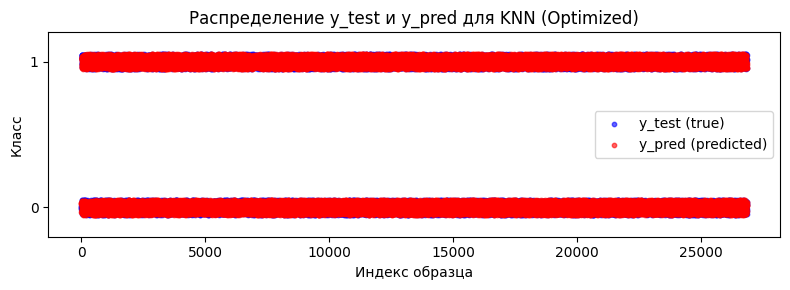

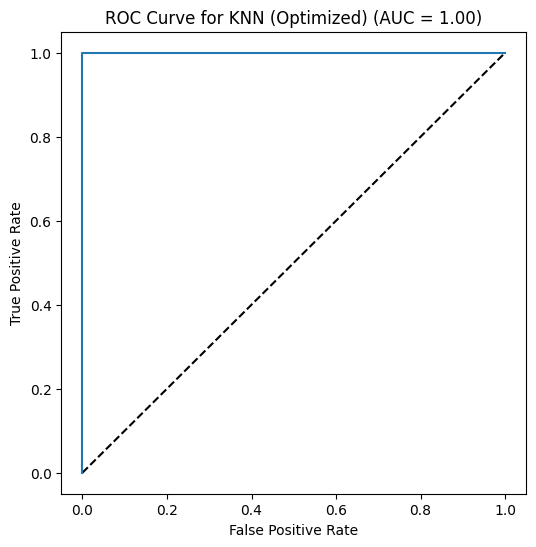

AUC: 1.00


In [27]:
# study_knn = optuna.create_study(direction='maximize')
# study_knn.optimize(objective_knn, n_trials=50)
# print("Лучшие параметры для KNN:", study_knn.best_params)
# knn_best = KNeighborsClassifier(**study_knn.best_params)
knn_best = KNeighborsClassifier(n_neighbors=3, weights='uniform', metric='manhattan')
knn_best.fit(X_train, y_train)
evaluate_model(knn_best, X_test, y_test, "KNN (Optimized)")

models.append(knn_best)

### SVM

In [28]:
X_small, y_small = resample(X_train, y_train, n_samples=5000, random_state=42, replace=False)

In [29]:
def exponential_kernel(X, Y):
    gamma = 0.1
    return np.exp(-gamma * pairwise_distances(X, Y, metric='euclidean'))


--- SVM (Exponential Kernel) ---
Classification Report:
              precision    recall  f1-score   support

       False       1.00      1.00      1.00     13428
        True       1.00      1.00      1.00     13427

    accuracy                           1.00     26855
   macro avg       1.00      1.00      1.00     26855
weighted avg       1.00      1.00      1.00     26855

Confusion Matrix:
[[13422     6]
 [    8 13419]]
F1-score: 0.9995


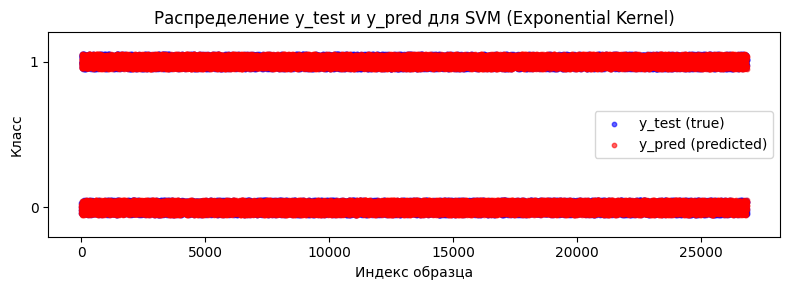

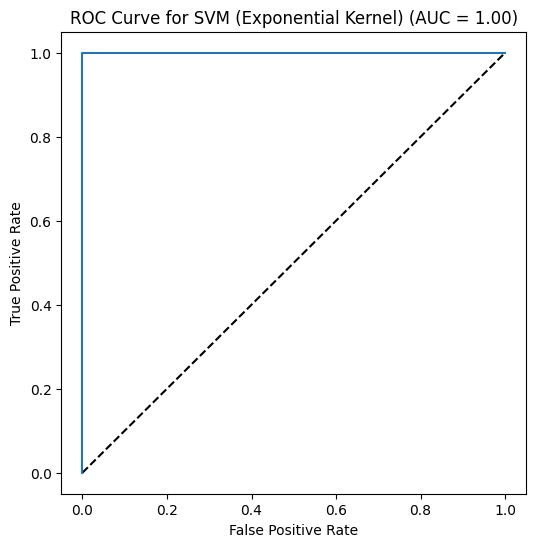

AUC: 1.00


In [30]:
svc_exp = SVC(kernel=exponential_kernel, probability=True)
svc_exp.fit(X_small, y_small)
evaluate_model(svc_exp, X_test, y_test, "SVM (Exponential Kernel)")

models.append(svc_exp)


--- SVM (linear Kernel) ---
Classification Report:
              precision    recall  f1-score   support

       False       1.00      1.00      1.00     13428
        True       1.00      1.00      1.00     13427

    accuracy                           1.00     26855
   macro avg       1.00      1.00      1.00     26855
weighted avg       1.00      1.00      1.00     26855

Confusion Matrix:
[[13421     7]
 [   37 13390]]
F1-score: 0.9984


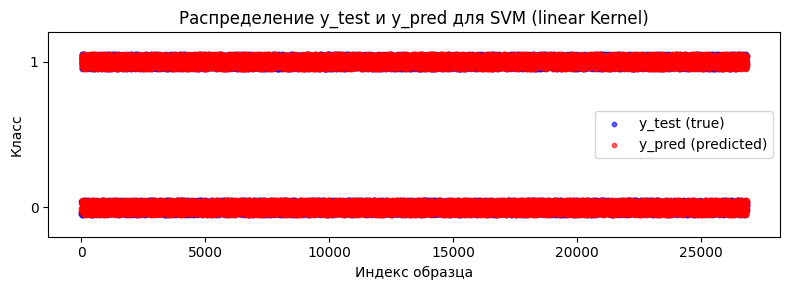

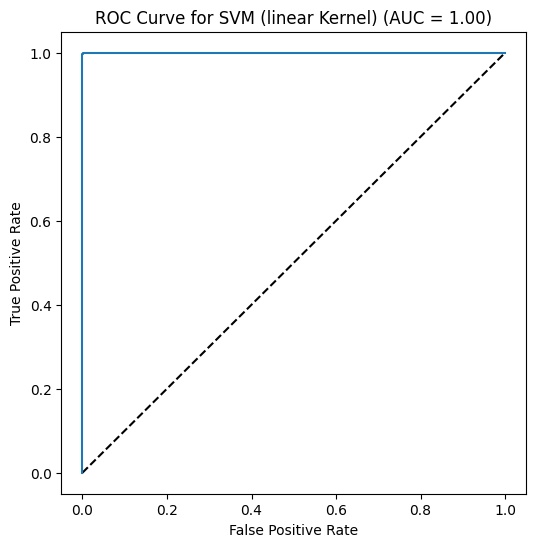

AUC: 1.00

--- SVM (poly Kernel) ---
Classification Report:
              precision    recall  f1-score   support

       False       0.56      1.00      0.72     13428
        True       0.99      0.22      0.36     13427

    accuracy                           0.61     26855
   macro avg       0.78      0.61      0.54     26855
weighted avg       0.78      0.61      0.54     26855

Confusion Matrix:
[[13402    26]
 [10513  2914]]
F1-score: 0.3561


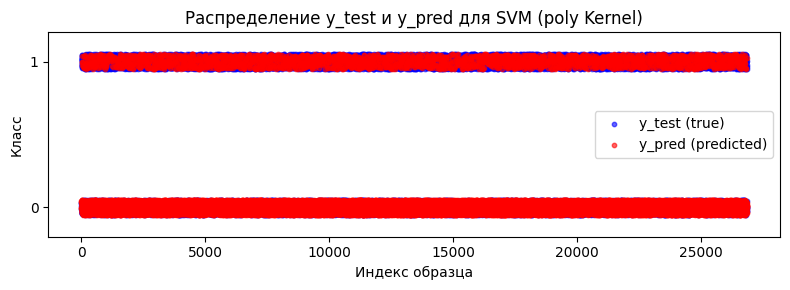

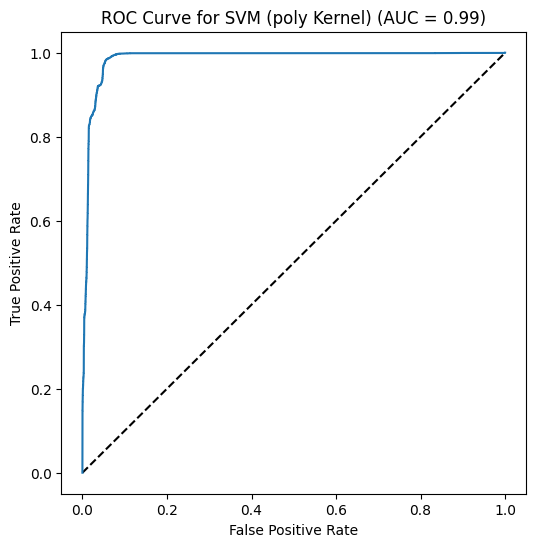

AUC: 0.99

--- SVM (rbf Kernel) ---
Classification Report:
              precision    recall  f1-score   support

       False       0.94      1.00      0.97     13428
        True       1.00      0.94      0.97     13427

    accuracy                           0.97     26855
   macro avg       0.97      0.97      0.97     26855
weighted avg       0.97      0.97      0.97     26855

Confusion Matrix:
[[13421     7]
 [  849 12578]]
F1-score: 0.9671


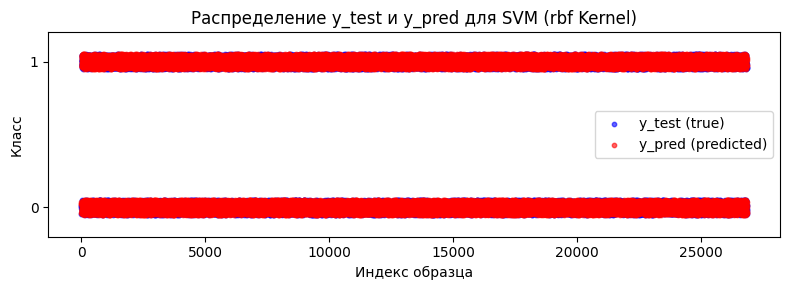

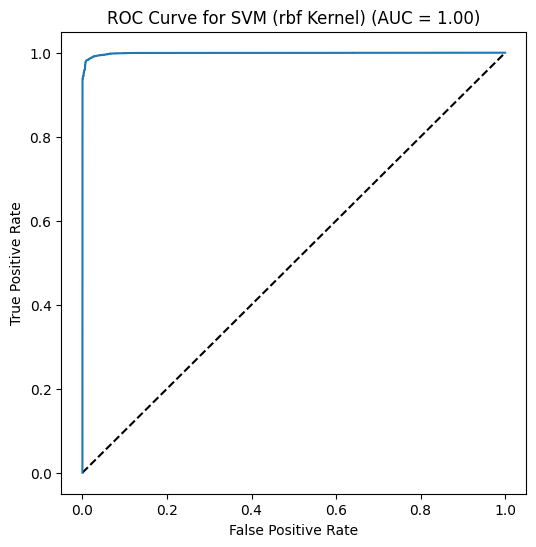

AUC: 1.00

--- SVM (sigmoid Kernel) ---
Classification Report:
              precision    recall  f1-score   support

       False       0.92      0.87      0.90     13428
        True       0.88      0.93      0.90     13427

    accuracy                           0.90     26855
   macro avg       0.90      0.90      0.90     26855
weighted avg       0.90      0.90      0.90     26855

Confusion Matrix:
[[11691  1737]
 [  997 12430]]
F1-score: 0.9009


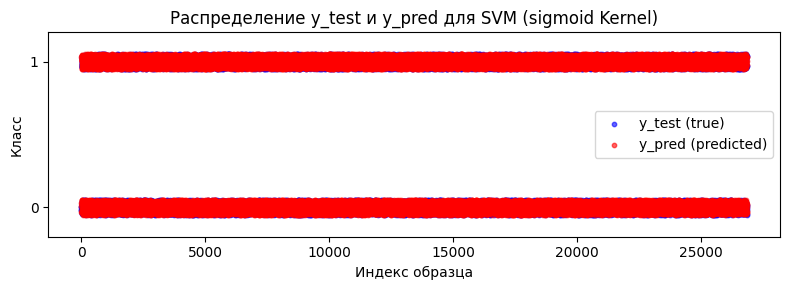

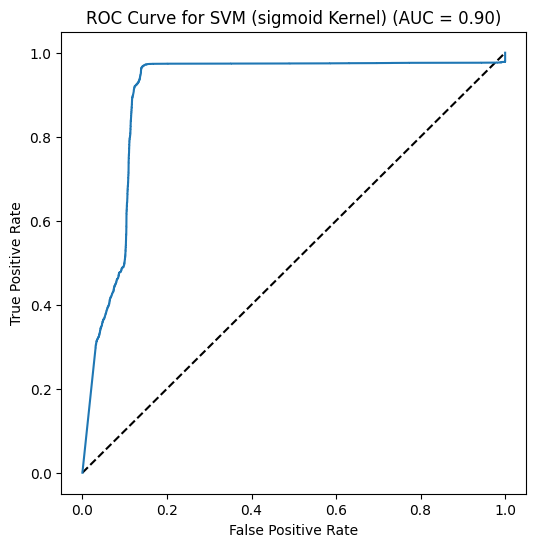

AUC: 0.90


In [31]:
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
for kernel in kernels:
    svc = SVC(kernel=kernel, probability=True, random_state=42)
    svc.fit(X_small, y_small)
    evaluate_model(svc, X_test, y_test, f"SVM ({kernel} Kernel)")

    models.append(svc)

In [32]:
def compare_models(models, model_names, X_test, y_test):
    results = []

    for model, name in zip(models, model_names):
        metrics = evaluate_model(model, X_test, y_test, model_name=name, verbose=False)
        results.append(metrics)

    df = pd.DataFrame(results)

    plt.figure(figsize=(10, 5))
    sns.barplot(data=df, x="model", y="f1", palette="Blues_d")
    plt.title("Сравнение моделей по F1-score")
    plt.ylabel("F1-score")
    plt.ylim(0, 1)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    sns.barplot(data=df, x="model", y="auc", palette="Greens_d")
    plt.title("Сравнение моделей по AUC")
    plt.ylabel("AUC")
    plt.ylim(0, 1)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return df

C:\Users\andre\AppData\Local\Temp\ipykernel_1920\1954530782.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="model", y="f1", palette="Blues_d")


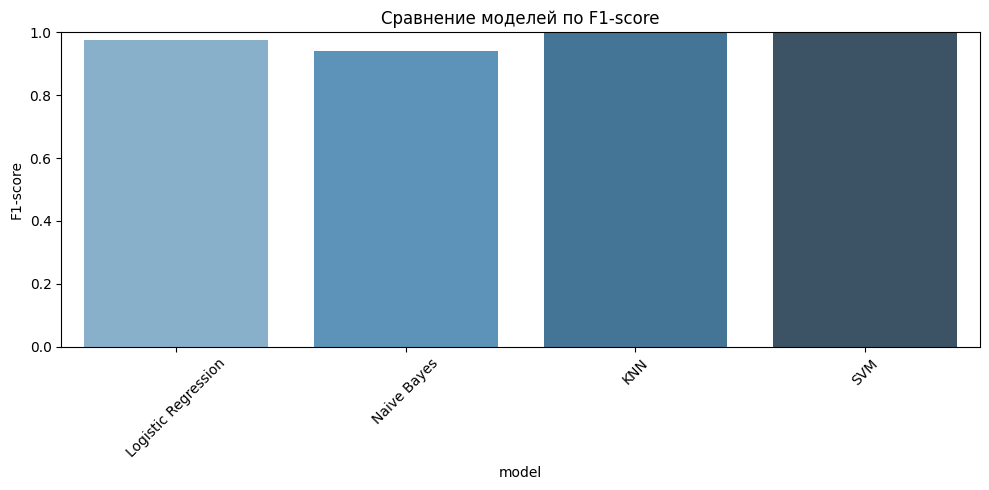

C:\Users\andre\AppData\Local\Temp\ipykernel_1920\1954530782.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="model", y="auc", palette="Greens_d")


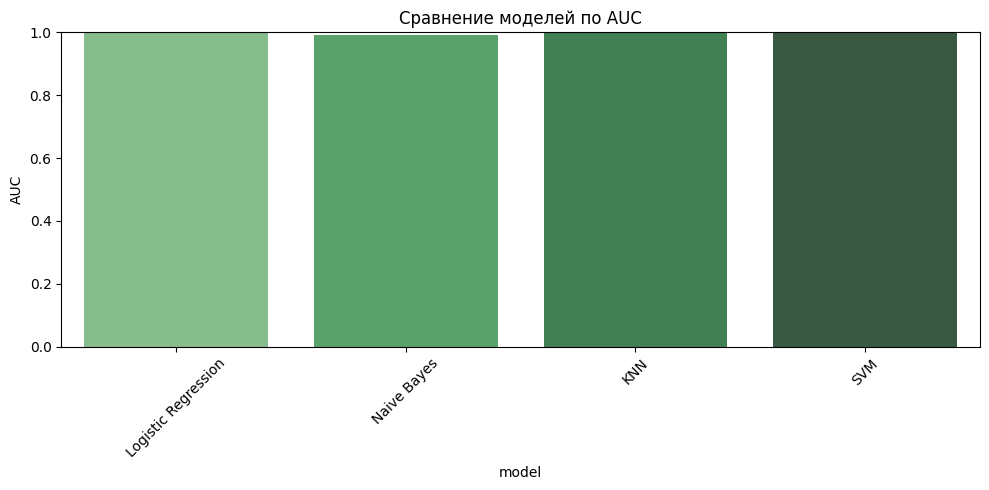

In [33]:
model_names = ['Logistic Regression', 'Naive Bayes', 'KNN', 'SVM']

compare_df = compare_models(models, model_names, X_test, y_test)

### KNN KFold 

In [34]:
scores = cross_val_score(knn_best, X_scaled, y, cv=kfold, scoring='accuracy')
print("Кросс-валидация (k-fold):")
print(f"Точность для каждого фолда: {scores}")
print(f"Средняя точность: {np.mean(scores):.4f}")
print(f"Стандартное отклонение: {np.std(scores):.4f}")

Кросс-валидация (k-fold):
Точность для каждого фолда: [1. 1. 1. 1. 1.]
Средняя точность: 1.0000
Стандартное отклонение: 0.0000


### KNN моя цена

In [39]:
knn = KNNHandMade(n_neighbors=3, metric='manhattan', weights='uniform')
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print(classification_report(y_test, y_pred))

KeyboardInterrupt: 

In [36]:
import pandas as pd
import pickle
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

knn_best = KNeighborsClassifier(n_neighbors=3, weights='uniform', metric='manhattan')
knn_best.fit(X_train, y_train)

# Сохранение модели
model_path = "knn.pkl"
try:
    with open(model_path, 'wb') as file:
        pickle.dump(knn_best, file)
    print(f"Модель успешно сохранена в {model_path}")
except Exception as e:
    print(f"Ошибка при сохранении модели: {e}")

# # Опционально: сохранение scaler, если он нужен для предсказаний
# scaler_path = "scaler.pkl"
# try:
#     with open(scaler_path, 'wb') as file:
#         pickle.dump(scaler, file)
#     print(f"Scaler успешно сохранён в {scaler_path}")
# except Exception as e:
#     print(f"Ошибка при сохранении scaler: {e}")

Модель успешно сохранена в knn.pkl


In [37]:
with open(model_path, 'rb') as file:
    loaded_model = pickle.load(file)
print("Модель успешно загружена")

Модель успешно загружена
